# Logistic Regression — Philippine Employee Stagnation

Predicts `is_stagnant` (binary) using demographic and labour-market features.

**Contents:**
1. Load processed train/test data
2. Standardise features
3. Train logistic regression (balanced class weights)
4. Sigmoid curve visualisation
5. Classification report
6. Precision-Recall curve and AUC-PR
7. ROC-AUC
8. Coefficient analysis (feature importance)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay,
)
import joblib

BASE = os.path.join(os.path.dirname(os.getcwd()), 'ph-lfs-stagnation - Copy - Copy - Copy')
if not os.path.exists(os.path.join(BASE, 'data')):
    BASE = os.path.dirname(os.getcwd())
if not os.path.exists(os.path.join(BASE, 'data')):
    BASE = os.getcwd()

DATA_DIR   = os.path.join(BASE, 'data')
MODELS_DIR = os.path.join(BASE, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)
print('BASE:', BASE)

BASE: c:\Users\clyde\Desktop\ph-lfs-stagnation - Copy - Copy - Copy


## 1. Load Data

In [2]:
X_train = pd.read_csv(os.path.join(DATA_DIR, 'X_train.csv'))
X_test  = pd.read_csv(os.path.join(DATA_DIR, 'X_test.csv'))
y_train = pd.read_csv(os.path.join(DATA_DIR, 'y_train.csv')).squeeze()
y_test  = pd.read_csv(os.path.join(DATA_DIR, 'y_test.csv')).squeeze()

FEATURE_COLS = X_train.columns.tolist()
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train stagnation rate: {y_train.mean()*100:.2f}%')
print(f'Test  stagnation rate: {y_test.mean()*100:.2f}%')
print('\nFeatures:', FEATURE_COLS)

Train: (2060789, 14)  |  Test: (679707, 14)
Train stagnation rate: 8.45%
Test  stagnation rate: 6.95%

Features: ['age', 'sex', 'marital_status', 'region', 'urban_rural', 'hh_size', 'education_level', 'occupation_major', 'industry_sector', 'normal_hours', 'actual_hours', 'month_sin', 'month_cos', 'gdp_per_employed']


## 2. Train Logistic Regression

**Design choices:**
- `class_weight='balanced'`: re-weights the loss proportional to inverse class frequency — mathematically equivalent to oversampling the minority class without duplicating data
- `C=1.0`: default L2 regularisation strength
- `solver='saga'`: stochastic gradient descent variant; handles large datasets efficiently
- Standardised features (mean=0, std=1) via `StandardScaler` so coefficients are directly comparable

In [3]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        C=1.0,
        class_weight='balanced',
        solver='saga',
        max_iter=500,
        random_state=42,
        n_jobs=-1,
    ))
])

print('Fitting...')
pipe.fit(X_train, y_train)
print('Done.')
joblib.dump(pipe, os.path.join(MODELS_DIR, 'logistic_regression.pkl'))
print('Saved to models/logistic_regression.pkl')

Fitting...
Done.
Saved to models/logistic_regression.pkl


## 3. Sigmoid Curve Visualisation

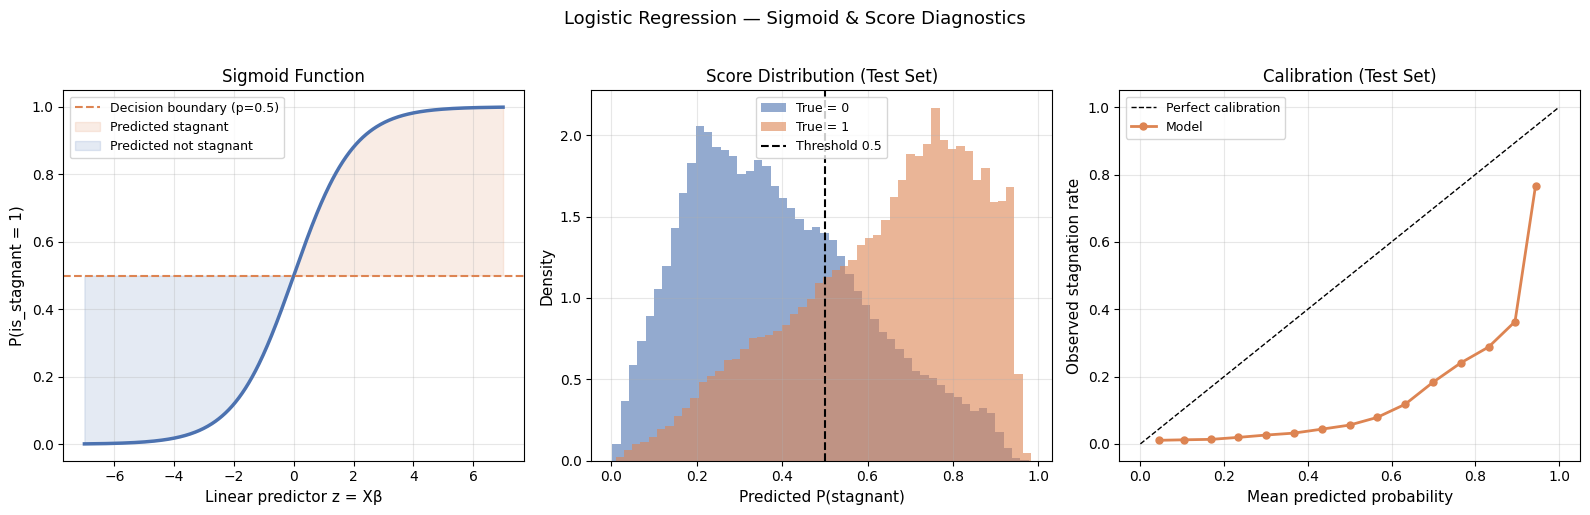

In [4]:
y_prob_train = pipe.predict_proba(X_train)[:, 1]
y_prob_test  = pipe.predict_proba(X_test)[:, 1]
y_pred_test  = pipe.predict(X_test)

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

# --- Panel 1: Sigmoid function ---
ax1 = fig.add_subplot(gs[0])
z   = np.linspace(-7, 7, 500)
sig = 1 / (1 + np.exp(-z))
ax1.plot(z, sig, color='#4C72B0', linewidth=2.5)
ax1.axhline(0.5, color='#DD8452', linestyle='--', linewidth=1.5, label='Decision boundary (p=0.5)')
ax1.fill_between(z, sig, 0.5, where=(sig > 0.5), alpha=0.15, color='#DD8452', label='Predicted stagnant')
ax1.fill_between(z, sig, 0.5, where=(sig < 0.5), alpha=0.15, color='#4C72B0', label='Predicted not stagnant')
ax1.set_xlabel('Linear predictor z = X\u03b2', fontsize=11)
ax1.set_ylabel('P(is_stagnant = 1)', fontsize=11)
ax1.set_title('Sigmoid Function', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Panel 2: Predicted probability histogram ---
ax2 = fig.add_subplot(gs[1])
for label, colour in [(0, '#4C72B0'), (1, '#DD8452')]:
    mask = (y_test == label).values
    ax2.hist(y_prob_test[mask], bins=50, alpha=0.6, color=colour,
             density=True, label=f'True = {label}')
ax2.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold 0.5')
ax2.set_xlabel('Predicted P(stagnant)', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.set_title('Score Distribution (Test Set)', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# --- Panel 3: Calibration ---
ax3 = fig.add_subplot(gs[2])
n_bins = 15
bins = np.linspace(0, 1, n_bins + 1)
bin_idx = np.digitize(y_prob_test, bins) - 1
b_means, b_obs = [], []
for b in range(n_bins):
    m = bin_idx == b
    if m.sum() >= 10:
        b_means.append(y_prob_test[m].mean())
        b_obs.append(np.array(y_test)[m].mean())
ax3.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
ax3.plot(b_means, b_obs, 'o-', color='#DD8452', linewidth=2, markersize=5, label='Model')
ax3.set_xlabel('Mean predicted probability', fontsize=11)
ax3.set_ylabel('Observed stagnation rate', fontsize=11)
ax3.set_title('Calibration (Test Set)', fontsize=12)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.suptitle('Logistic Regression — Sigmoid & Score Diagnostics', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'sigmoid_diagnostics.png'), dpi=120, bbox_inches='tight')
plt.show()

## 4. Classification Report

CLASSIFICATION REPORT  (threshold = 0.5)
                  precision    recall  f1-score   support

Not Stagnant (0)     0.9736    0.7162    0.8253    632489
    Stagnant (1)     0.1628    0.7395    0.2669     47218

        accuracy                         0.7178    679707
       macro avg     0.5682    0.7278    0.5461    679707
    weighted avg     0.9172    0.7178    0.7865    679707



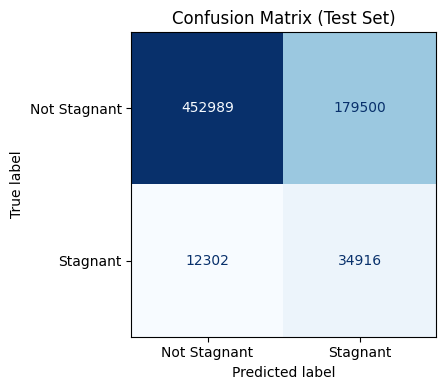

In [5]:
print('=' * 55)
print('CLASSIFICATION REPORT  (threshold = 0.5)')
print('=' * 55)
print(classification_report(
    y_test, y_pred_test,
    target_names=['Not Stagnant (0)', 'Stagnant (1)'],
    digits=4
))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm, display_labels=['Not Stagnant', 'Stagnant']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'confusion_matrix.png'), dpi=120, bbox_inches='tight')
plt.show()

## 5. Precision-Recall and ROC Curves

**Why AUC-PR is the primary metric here:** With class imbalance, ROC-AUC is inflated by the large number of true negatives. AUC-PR (average precision) measures how well the model identifies the minority stagnant class across all possible thresholds — it is much more sensitive to improvements in minority class performance.

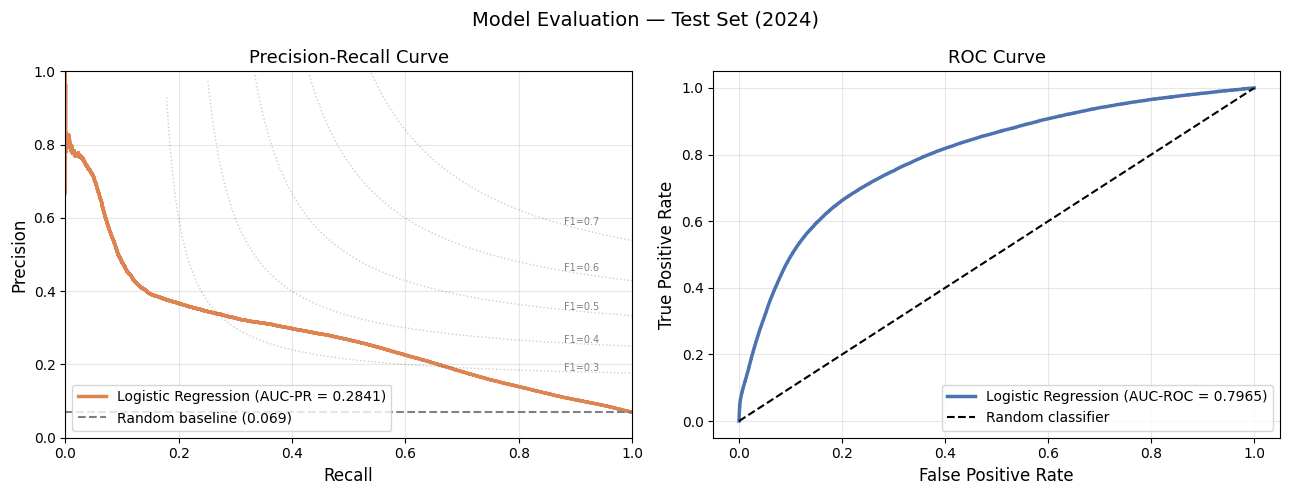

AUC-PR  (Average Precision): 0.2841
AUC-ROC                    : 0.7965


In [6]:
ap_score = average_precision_score(y_test, y_prob_test)
roc_auc  = roc_auc_score(y_test, y_prob_test)

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob_test)
fpr, tpr, _                      = roc_curve(y_test, y_prob_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# PR Curve
ax = axes[0]
ax.plot(recall, precision, color='#DD8452', linewidth=2.5,
        label=f'Logistic Regression (AUC-PR = {ap_score:.4f})')
ax.axhline(y_test.mean(), color='grey', linestyle='--', linewidth=1.5,
           label=f'Random baseline ({y_test.mean():.3f})')
for f1 in [0.3, 0.4, 0.5, 0.6, 0.7]:
    x_f1 = np.linspace(0.01, 1, 300)
    y_f1 = f1 * x_f1 / (2 * x_f1 - f1)
    valid = (y_f1 >= 0) & (y_f1 <= 1)
    ax.plot(x_f1[valid], y_f1[valid], 'k:', alpha=0.2, linewidth=1)
    idx = np.argmin(np.abs(x_f1 - 0.88))
    if valid[idx]:
        ax.annotate(f'F1={f1}', (x_f1[idx], y_f1[idx]), fontsize=7, color='gray')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
ax.set_xlabel('Recall', fontsize=12); ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

# ROC Curve
ax = axes[1]
ax.plot(fpr, tpr, color='#4C72B0', linewidth=2.5,
        label=f'Logistic Regression (AUC-ROC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.suptitle('Model Evaluation — Test Set (2024)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'pr_roc_curves.png'), dpi=120, bbox_inches='tight')
plt.show()

print(f'AUC-PR  (Average Precision): {ap_score:.4f}')
print(f'AUC-ROC                    : {roc_auc:.4f}')

## 6. Optimal Threshold

Optimal threshold (max F1-stagnant): 0.6959
F1 at optimal threshold            : 0.3494

Classification report at threshold = 0.6959:
              precision    recall  f1-score   support

Not Stagnant     0.9583    0.9090    0.9330    632489
    Stagnant     0.2781    0.4698    0.3494     47218

    accuracy                         0.8785    679707
   macro avg     0.6182    0.6894    0.6412    679707
weighted avg     0.9110    0.8785    0.8924    679707



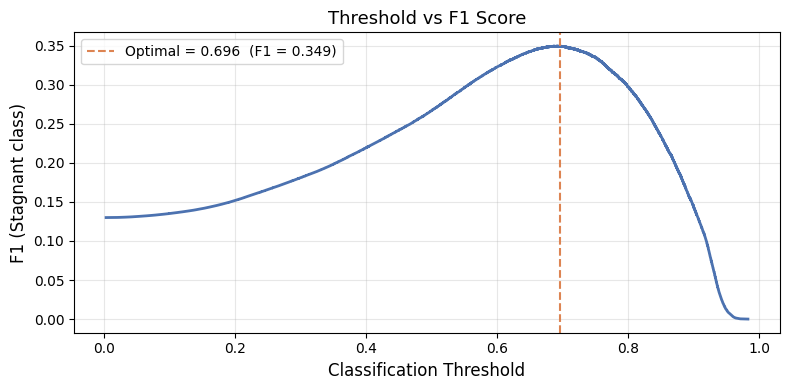

In [7]:
f1_arr = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)
best_idx  = np.argmax(f1_arr)
best_thr  = pr_thresholds[best_idx]
best_f1   = f1_arr[best_idx]

print(f'Optimal threshold (max F1-stagnant): {best_thr:.4f}')
print(f'F1 at optimal threshold            : {best_f1:.4f}')

y_pred_opt = (y_prob_test >= best_thr).astype(int)
print(f'\nClassification report at threshold = {best_thr:.4f}:')
print(classification_report(y_test, y_pred_opt,
                             target_names=['Not Stagnant', 'Stagnant'], digits=4))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pr_thresholds, f1_arr, color='#4C72B0', linewidth=2)
ax.axvline(best_thr, color='#DD8452', linestyle='--', linewidth=1.5,
           label=f'Optimal = {best_thr:.3f}  (F1 = {best_f1:.3f})')
ax.set_xlabel('Classification Threshold', fontsize=12)
ax.set_ylabel('F1 (Stagnant class)', fontsize=12)
ax.set_title('Threshold vs F1 Score', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'threshold_f1.png'), dpi=120, bbox_inches='tight')
plt.show()

## 7. Feature Importance (Standardised Coefficients)

Feature coefficients (sorted ascending):
         feature  coefficient  odds_ratio
    actual_hours    -0.882357    0.413806
             age    -0.217615    0.804435
       month_cos    -0.098367    0.906316
 industry_sector    -0.051495    0.949809
       month_sin    -0.046548    0.954519
gdp_per_employed     0.012163    1.012237
          region     0.020853    1.021072
  marital_status     0.032731    1.033273
             sex     0.035654    1.036297
         hh_size     0.048178    1.049357
     urban_rural     0.110918    1.117304
    normal_hours     0.204230    1.226581
 education_level     0.358631    1.431369
occupation_major     0.853024    2.346732


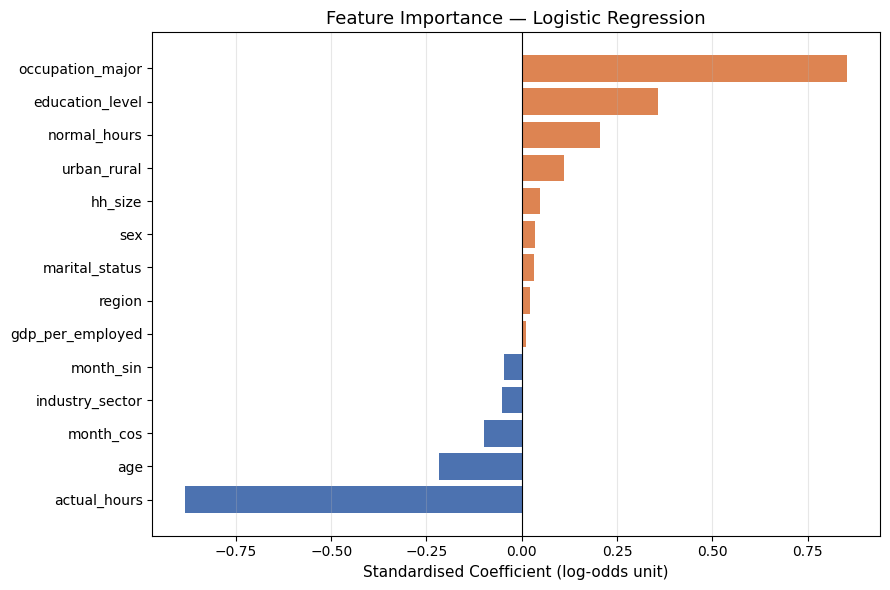

In [8]:
coef = pipe.named_steps['clf'].coef_[0]
coef_df = pd.DataFrame({
    'feature':     FEATURE_COLS,
    'coefficient': coef,
    'odds_ratio':  np.exp(coef),
}).sort_values('coefficient')

print('Feature coefficients (sorted ascending):')
print(coef_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
colours = ['#DD8452' if c > 0 else '#4C72B0' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colours)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardised Coefficient (log-odds unit)', fontsize=11)
ax.set_title('Feature Importance — Logistic Regression', fontsize=13)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'feature_importance.png'), dpi=120, bbox_inches='tight')
plt.show()

## 8. Summary

In [9]:
print('=' * 55)
print('RESULTS SUMMARY')
print('=' * 55)
print(f'Train samples    : {len(X_train):,}  (2021-2023)')
print(f'Test samples     : {len(X_test):,}   (2024)')
print(f'Features         : {len(FEATURE_COLS)}')
print(f'AUC-PR           : {ap_score:.4f}')
print(f'AUC-ROC          : {roc_auc:.4f}')
print(f'Optimal threshold: {best_thr:.4f}')
print(f'F1 @ optimal thr : {best_f1:.4f}')
print('\nTop stagnation risk factors:')
for _, row in coef_df.tail(5).iterrows():
    print(f'  {row["feature"]:<22} coef={row["coefficient"]:+.4f}  OR={row["odds_ratio"]:.3f}')

RESULTS SUMMARY
Train samples    : 2,060,789  (2021-2023)
Test samples     : 679,707   (2024)
Features         : 14
AUC-PR           : 0.2841
AUC-ROC          : 0.7965
Optimal threshold: 0.6959
F1 @ optimal thr : 0.3494

Top stagnation risk factors:
  hh_size                coef=+0.0482  OR=1.049
  urban_rural            coef=+0.1109  OR=1.117
  normal_hours           coef=+0.2042  OR=1.227
  education_level        coef=+0.3586  OR=1.431
  occupation_major       coef=+0.8530  OR=2.347
